In [1]:
import os
import sys
path = os.getcwd()
while True:
    if 'utils.py' in os.listdir(path):
        if path not in sys.path:
            sys.path.append(path)
        break
    new_path = os.path.dirname(path)
    if new_path == path:
        upload_utils = files.upload()
        break
    path = new_path

import utils

/opt/anaconda3/envs/nlp/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/QNLI_Notebooks/QNLI_gemma_2_9b_it/Results/checkpoint_qnli_gemma_2_9b_it_4bit_zero_shot_chat_template.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/QNLI_Notebooks/QNLI_gemma_2_9b_it/Results/checkpoint_qnli_gemma_2_9b_it_4bit_few_shot_1_examples_entailment_chat_template.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/QNLI_Notebooks/QNLI_gemma_2_9b_it/Results/checkpoint_qnli_gemma_2_9b_it_4bit_few_shot_1_examples_not_entailment_chat_template.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/QNLI_Notebooks/QNLI_gemma_2_9b_it/Results/checkpoint_qnli_gemma_2_9b_it_4bit_few_shot_2_examples_chat_template.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/QNLI_Notebooks/QNLI_gemma_2_9b_it/Results/checkpoint_qnli_gemma_2_9b_it_4bit_few_shot_3_examples_chat_template.

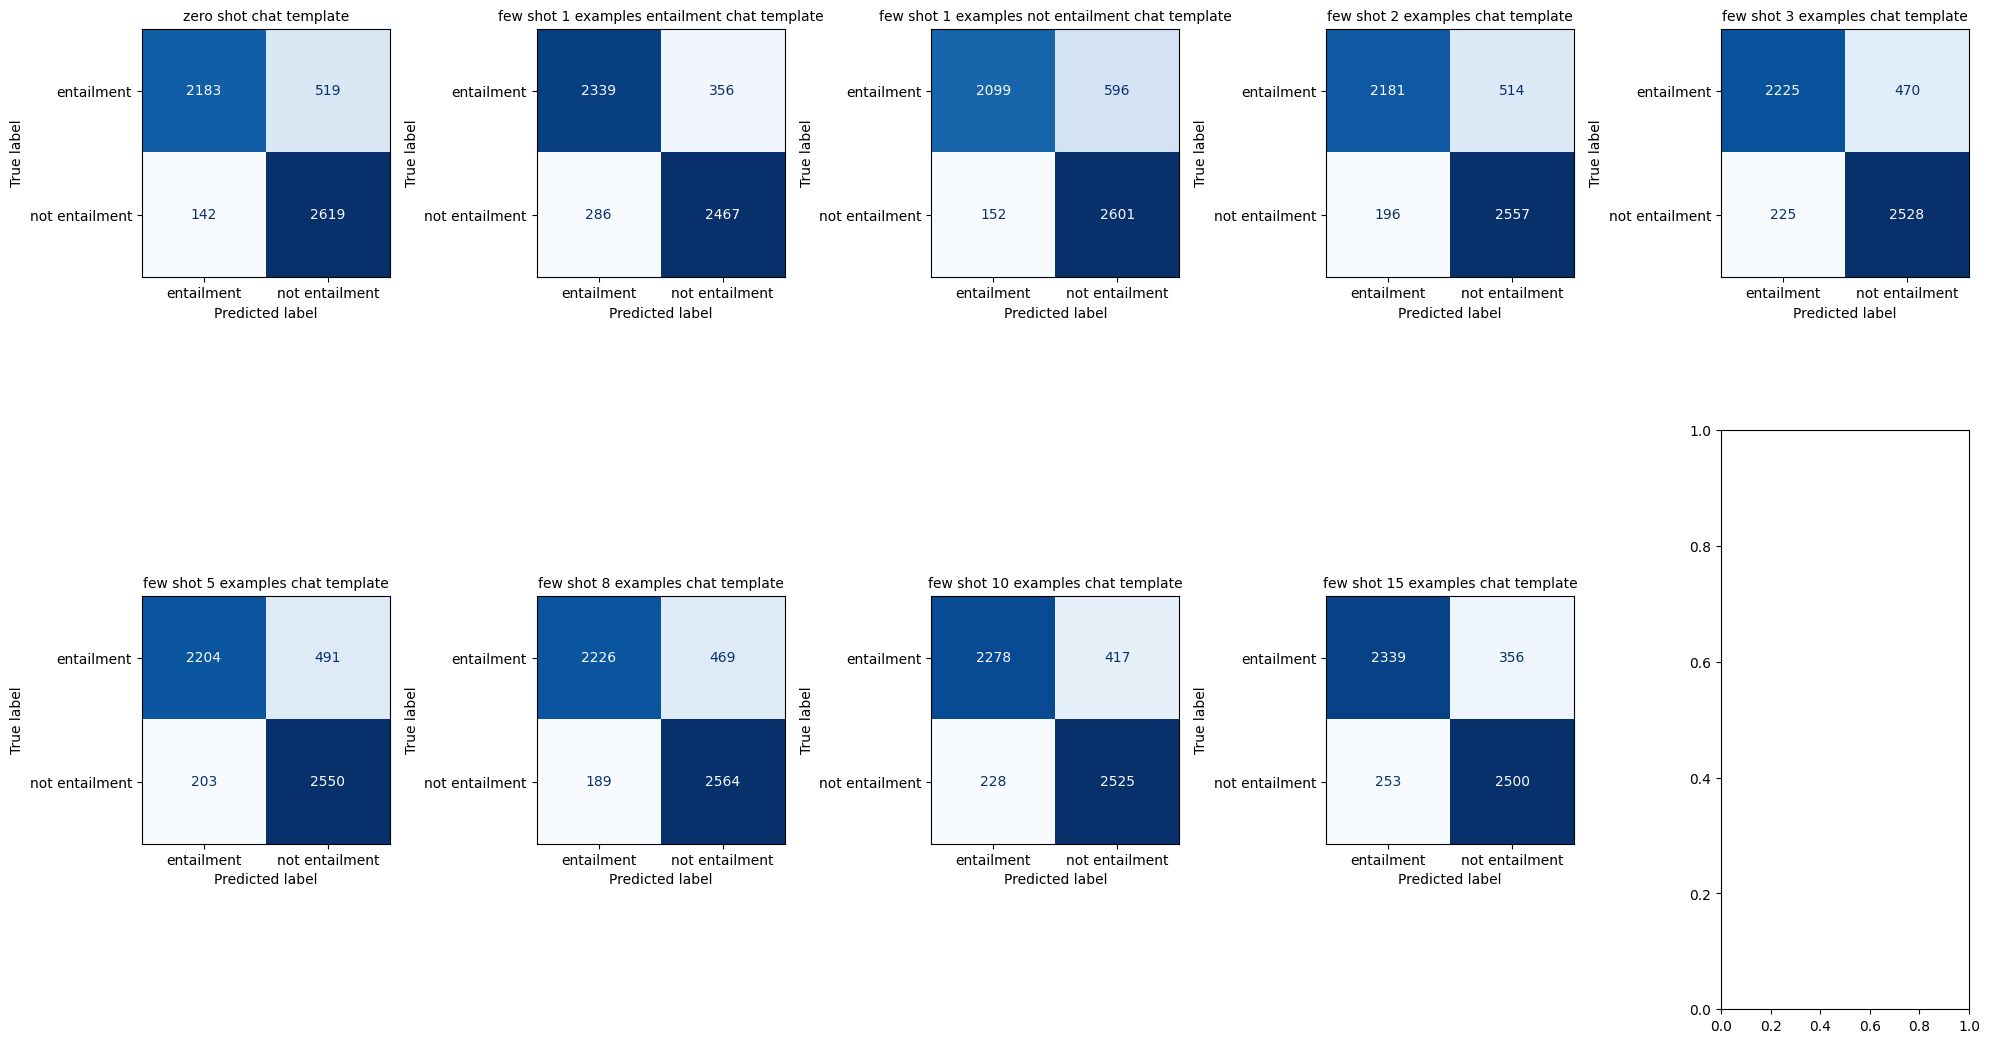

In [4]:
import matplotlib.pyplot as plt

training_modes = [
    'zero shot chat template',
    'few shot 1 examples entailment chat template',
    'few shot 1 examples not entailment chat template',
    'few shot 2 examples chat template',
    'few shot 3 examples chat template',
    'few shot 5 examples chat template',
    'few shot 8 examples chat template',
    'few shot 10 examples chat template',
    'few shot 15 examples chat template'    
]

fig, axes = plt.subplots(2, 5, figsize=(20,12))
axes = axes.flatten()
accs, precisions, recalls, f1s, mccs, kappas = [], [], [], [], [], []

idx = 0
for mode in training_modes:
    global_params = {
            'dataset_type': 'qnli',
            'quantization': '4bit',
            'training_mode': mode,
            'model_id': 'google/gemma-2-9b-it'}
   
    checkpoint_path = utils.create_checkpoint_path(params=global_params)
    predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)

    acc, precision, recall, f1, mcc, kappa = utils.get_metrics(
                                            predicted_labels=predicted_labels,
                                            gold_labels=gold_labels,
                                            params=global_params,
                                            ax=axes[idx]
                                            )   
    accs.append(round(acc, 4))
    precisions.append(round(precision, 4))
    recalls.append(round(recall, 4))
    f1s.append(round(f1, 4))
    mccs.append(round(mcc, 4))
    kappas.append(round(kappa, 4))

    idx += 1


plt.tight_layout()
plt.show()

In [10]:
import pandas as pd
labels = [
    "0 examples",
    "1 example (entailment)",
    "1 example (not entailment)",
    "2 examples",
    "3 examples",
    "5 examples",
    "8 examples",
    "10 examples",
    "15 examples"
]

metrics_df = pd.DataFrame(
    {"Accuracy": accs,
     "Precision": precisions,
     "Recalls": recalls,
    "F1": f1s,
    "MCC": mccs,
    "Kappa": kappas},
    index= labels
)
metrics_df

,Accuracy,Precision,Recalls,F1,MCC,Kappa
0 examples,0.8790,0.8868,0.8782,0.8782,0.7650,0.7576
1 example (entailment),0.8822,0.8825,0.8820,0.8821,0.7645,0.7642
1 example (not entailment),0.8627,0.8730,0.8618,0.8615,0.7348,0.7249
2 examples,0.8697,0.8751,0.8690,0.8691,0.7441,0.7390
3 examples,0.8724,0.8757,0.8719,0.8720,0.7476,0.7446
5 examples,0.8726,0.8771,0.8720,0.8721,0.7491,0.7449
8 examples,0.8792,0.8836,0.8787,0.8788,0.7622,0.7582
10 examples,0.8816,0.8836,0.8812,0.8814,0.7649,0.7630
15 examples,0.8882,0.8889,0.8880,0.8881,0.7769,0.7763


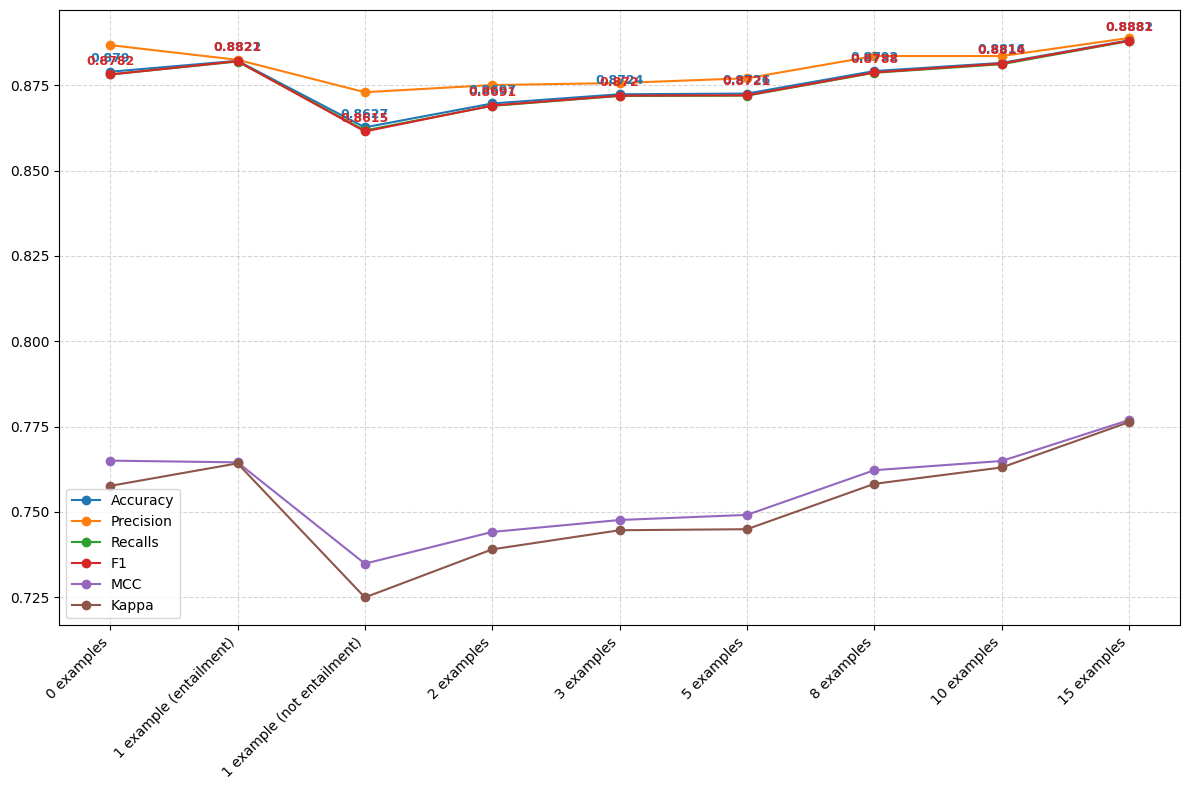

In [11]:
fig, ax = plt.subplots(figsize=(12, 8))

# plot all metrics
metrics_df.plot(kind='line', ax=ax, marker='o')

# set custom x-axis labels
ax.set_xticks(range(len(metrics_df.index)))
ax.set_xticklabels(metrics_df.index, rotation=45, ha='right')

# show grid
ax.grid(True, linestyle='--', alpha=0.5)

# annotate only Accuracy and F1
for metric in ["Accuracy", "F1"]:
    for x, y in enumerate(metrics_df[metric]):
        ax.text(x, y + 0.002, str(y), ha='center', va='bottom', fontsize=9, fontweight='bold', color=ax.get_lines()[list(metrics_df.columns).index(metric)].get_color())

plt.tight_layout()
plt.show()